<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Final)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.

Include both Part I and Part II to produce a self-contained notebook. You may fine-tune Part I codes and/or findings based on feedback received on Part I submission.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: 
#### Team: 
#### Members:
1. Chin Mun Yau
2. Hnit Oo Luck
3. Chua Dong En
4. Tan Sheng Yu
5. 

#### Dataset: 

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

In [50]:
import pandas as pd

wine_data = pd.read_csv("wine.csv")

**a.** Summarise the background of the dataset [limited to 50 words]

In [51]:
wine_data

,ID,Fixed_Acidity,Volatile_Acidity,Citric_Acid,Residual_Sugar,Chlorides,Free_SO2,Total_SO2,Density,pH,Sulphates,Alcohol,Quality
0,1,7.0,0.27,0.36,High,0.045,45.0,170.0,>1.00,Acidic,0.45,8%,6.0
1,2,6.3,0.30,0.34,Low,0.049,14.0,132.0,0.99-1.00,Acidic,0.49,9%,6.0
2,3,8.1,0.28,0.40,Low,0.050,30.0,97.0,0.99-1.00,Acidic,0.44,10%,6.0
3,4,7.2,0.23,0.32,Moderate,0.058,47.0,186.0,0.99-1.00,Acidic,0.40,9%,6.0
4,5,7.2,0.23,0.32,Moderate,0.058,47.0,186.0,0.99-1.00,Acidic,0.40,9%,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4843,4844,6.2,0.21,0.29,Low,0.039,24.0,92.0,0.99-1.00,Acidic,0.50,11%,6.0
4844,4845,6.6,0.32,0.36,Moderate,0.047,57.0,168.0,0.99-1.00,Acidic,0.46,9%,5.0
4845,4846,6.5,0.24,0.19,Low,0.041,30.0,111.0,0.99-1.00,Highly Acidic,0.46,9%,6.0
4846,4847,5.5,0.29,0.30,Low,0.021,20.0,110.0,<0.99,Acidic,0.38,12%,7.0


**Response.** 

<span style="color : lightblue;"> Looking at the data from wine.csv, it suggests that it stores certain chemical and physical properties of different wines. </span>

**b.** State the size of the dataset 

**Response.** 

<span style="color : lightblue;"> the data set is 4828 rows by 13 columns </span>

**c.** For each variable, describe what it represents and its data type (numerical or categorical)

**Response.**

<span style="color: lightblue;"> 
there are 13 variables: <br>
1. ID - Unique ID of the wine (categorical) <br>
2. Fixed_Acidity - The amount of tartaric acid, measured in g/dm3 (numerical) <br>
3. Volatile_Acidity - Acetic acid, measured in g/dm3 (numerical) <br>
4. Citric_Acid - Citric acid, measured in g/dm3 (numerical) <br>
5. Residual_Sugar - Level of residual sugar content (categorical) <br>
6. Chlorides - Sodium Chloride levels, measured in mg/dm3 (numerical) <br>
7. Free_SO2 - Free SO2 ions measured in mg/dm3 (numerical) <br>
8. Total_SO2 - Total SO2 ions measured in mg/dm3 (numerical) <br>
9. Density - Density measured in g/dm3 (categorical) <br>
10. pH - pH value (categorical) <br>
11. Sulphates - Levels of potassium sulphate, measured in g/dm3 (numerical) <br>
12. Alcohol - Alcohol content (categorical) <br>
13. Quality - Quality score (categorical) <br>
</span>

### 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

In [52]:
missing_percentage = (wine_data.isnull().sum() / len(wine_data)) * 100
print(missing_percentage)

ID                  0.000000
Fixed_Acidity       0.000000
Volatile_Acidity    0.000000
Citric_Acid         0.000000
Residual_Sugar      5.301155
Chlorides           0.000000
Free_SO2            0.000000
Total_SO2           0.000000
Density             0.000000
pH                  0.000000
Sulphates           0.000000
Alcohol             0.000000
Quality             5.321782
dtype: float64


In [53]:
RS = wine_data['Residual_Sugar'].mode()[0]
WD = wine_data['Quality'].median()

print(RS)
print(WD)

Low
6.0


<span style="color:lightblue"> Only the Residual_Sugar and Quality data have missing (null) data, each at around 5.3% of the data. A default "Low" value will be used for null Qualities, and a value of 6.0 for null Quality values. The rationale is to ensure that the data is least skewed by the 5% of null values present in both categories, hence we chose to replace the null Residual_Sugar category with the category's mode, and the null Quality category with its median. </span>

In [58]:
wine_data['Residual_Sugar'] = wine_data['Residual_Sugar'].fillna('Low')
wine_data['Quality'] = wine_data['Quality'].fillna(6.0)

**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

<span style="color:lightblue"> assumption: values above Q1 - 1.5 * IQR or Q3 + 1.5 * IQR are considered outliers </span>

In [59]:
for col in ['Fixed_Acidity', 'Volatile_Acidity', 'Citric_Acid', 'Chlorides', 'Free_SO2', 'Total_SO2', 'Sulphates']:

    Q1 = wine_data[col].quantile(0.25)
    Q3 = wine_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print(col,"Outliers:" , len(wine_data[(wine_data[col] < lower_bound) | (wine_data[col] > upper_bound)]))


Fixed_Acidity Outliers: 119
Volatile_Acidity Outliers: 183
Citric_Acid Outliers: 265
Chlorides Outliers: 206
Free_SO2 Outliers: 51
Total_SO2 Outliers: 24
Sulphates Outliers: 0


<span style="color:lightblue"> Based on the IQR assumption for outliers, we found various amount of outliers for the different numerical data, the outliers will be replaced with the maximum or minimum value within the range of [1.5 * IQR - Q1, 1.5 * IQR + Q3] </span>

In [60]:
wine_data[col] = wine_data[col].clip(lower=lower_bound, upper=upper_bound)

In [61]:
for col in ['Residual_Sugar', 'Density', 'pH', 'Alcohol']:
    print(f"\n{col}:")
    print(wine_data[col].value_counts())


Residual_Sugar:
Residual_Sugar
Low         2990
Moderate    1243
High         615
Name: count, dtype: int64

Density:
Density
0.99-1.00    4409
<0.99         344
>1.00          95
Name: count, dtype: int64

pH:
pH
Acidic           4379
Highly Acidic     432
Neutral            37
Name: count, dtype: int64

Alcohol:
Alcohol
9%     1585
10%    1248
11%     894
12%     667
8%      316
13%     131
14%       7
Name: count, dtype: int64


<span style="color:lightblue"> Looking at categorical data, there does not seem to be any outliers / wrong data input </span>

**Response.** 

**c.** For categorical variables, perform the necessary encoding.

<span style="color:lightblue"> Assumptions: ordinal encoding used since categorical variables (except ID and Quality) has a natural order </span>

In [62]:
residual_sugar_map = {'Low': 0, 'Moderate': 1, 'High': 2}
density_map = {'<0.99': 0, '0.99-1.00': 1, '>1.00': 2}
ph_map = {'Highly Acidic': 0, 'Acidic': 1}
alcohol_map = {'8%': 0, '9%': 1, '10%': 2, '11%': 3, '12%': 4}

wine_data['Residual_Sugar'] = wine_data['Residual_Sugar'].map(residual_sugar_map)
wine_data['Density'] = wine_data['Density'].map(density_map)
wine_data['pH'] = wine_data['pH'].map(ph_map)
wine_data['Alcohol'] = wine_data['Alcohol'].map(alcohol_map)

wine_data.head()

,ID,Fixed_Acidity,Volatile_Acidity,Citric_Acid,Residual_Sugar,Chlorides,Free_SO2,Total_SO2,Density,pH,Sulphates,Alcohol,Quality
0,1,7.0,0.27,0.36,2,0.045,45.0,170.0,2,1.0,0.45,0.0,6.0
1,2,6.3,0.30,0.34,0,0.049,14.0,132.0,1,1.0,0.49,1.0,6.0
2,3,8.1,0.28,0.40,0,0.050,30.0,97.0,1,1.0,0.44,2.0,6.0
3,4,7.2,0.23,0.32,1,0.058,47.0,186.0,1,1.0,0.40,1.0,6.0
4,5,7.2,0.23,0.32,1,0.058,47.0,186.0,1,1.0,0.40,1.0,6.0


**Response.** 

### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

**Response.** 

In [63]:
wine_data.describe()

,ID,Fixed_Acidity,Volatile_Acidity,Citric_Acid,Residual_Sugar,Chlorides,Free_SO2,Total_SO2,Density,pH,Sulphates,Alcohol,Quality
count,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4848.000000,4811.000000,4848.000000,4710.000000,4848.000000
mean,2424.500000,6.855311,0.277948,0.333987,0.510107,0.045740,35.321658,137.370854,0.948639,0.910206,0.487824,2.002335,5.885314
std,1399.641383,0.845380,0.100680,0.120828,0.709729,0.021825,17.027559,43.578295,0.296535,0.285916,0.107813,1.166803,0.861844
min,1.000000,3.800000,0.080000,0.000000,0.000000,0.009000,2.000000,6.000000,0.000000,0.000000,0.220000,0.000000,3.000000
25%,1212.750000,6.300000,0.210000,0.270000,0.000000,0.036000,23.000000,107.000000,1.000000,1.000000,0.410000,1.000000,5.000000
50%,2424.500000,6.800000,0.260000,0.320000,0.000000,0.043000,34.000000,134.000000,1.000000,1.000000,0.470000,2.000000,6.000000
75%,3636.250000,7.300000,0.320000,0.390000,1.000000,0.050000,46.000000,167.000000,1.000000,1.000000,0.550000,3.000000,6.000000
max,4848.000000,14.200000,1.100000,1.660000,2.000000,0.346000,289.000000,440.000000,2.000000,1.000000,0.760000,4.000000,9.000000


**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

**Response.** 

In [68]:

import pandas as pd
import numpy as np

wine_data = pd.read_csv("/Users/chinmunyau/Coding Stuff/[02] CS105/Lab 1/wine.csv")

numerical = ['Fixed_Acidity', 'Volatile_Acidity', 'Citric_Acid', 'Chlorides', 
             'Free_SO2', 'Total_SO2', 'Sulphates', 'Quality']

for col in numerical:
    s = wine_data[col].dropna()
    skew = s.skew()
    print(f"{col}: min={s.min():.3f}, max={s.max():.3f}, mean={s.mean():.3f}, median={s.median():.3f}, skew={skew:.3f}")


Fixed_Acidity: min=3.800, max=14.200, mean=6.855, median=6.800, skew=0.650
Volatile_Acidity: min=0.080, max=1.100, mean=0.278, median=0.260, skew=1.580
Citric_Acid: min=0.000, max=1.660, mean=0.334, median=0.320, skew=1.287
Chlorides: min=0.009, max=0.346, mean=0.046, median=0.043, skew=5.038
Free_SO2: min=2.000, max=289.000, mean=35.322, median=34.000, skew=1.410
Total_SO2: min=6.000, max=440.000, mean=137.371, median=134.000, skew=0.282
Sulphates: min=0.220, max=1.080, mean=0.490, median=0.470, skew=0.977
Quality: min=3.000, max=9.000, mean=5.879, median=6.000, skew=0.156


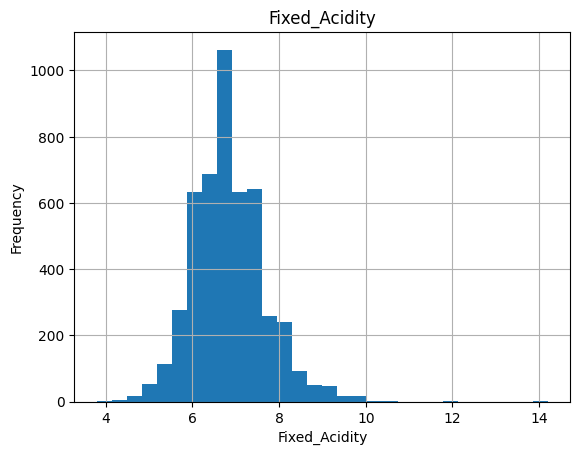

Observation (Fixed_Acidity): Slightly right-skewed (skew=0.65). Most wines have fixed acidity between 6-8 g/dm³, centered around 6.8.


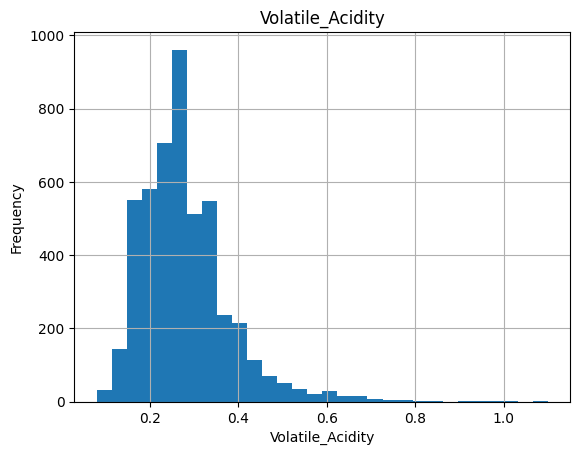

Observation (Volatile_Acidity): Moderately right-skewed (skew=1.58). Most wines have low volatile acidity, concentrated below 0.4 g/dm³, with a few high outliers.


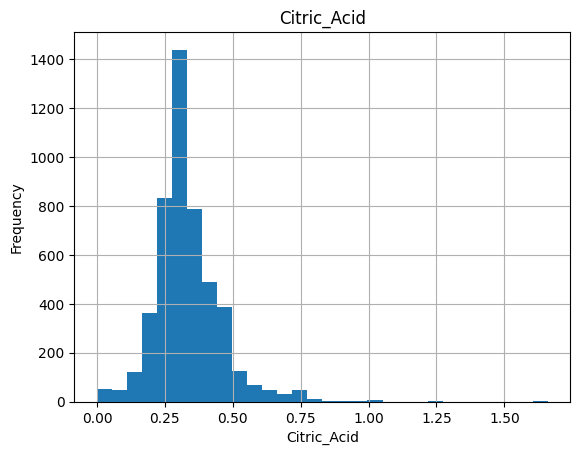

Observation (Citric_Acid): Right-skewed (skew=1.29). Values are concentrated at the lower end, with most wines below 0.5 g/dm³.


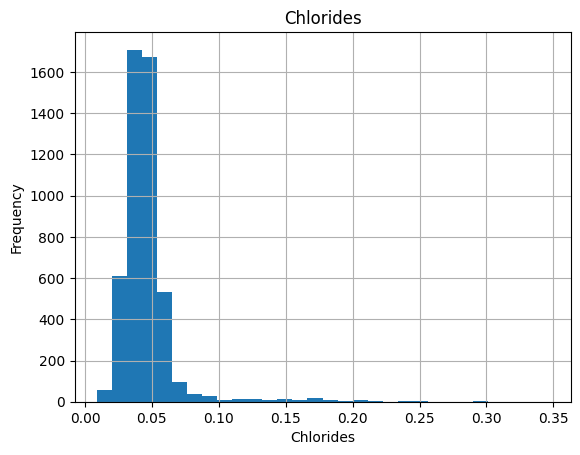

Observation (Chlorides): Highly right-skewed (skew=5.04). The vast majority of wines have very low chloride levels near 0.04, with a few extreme outliers.


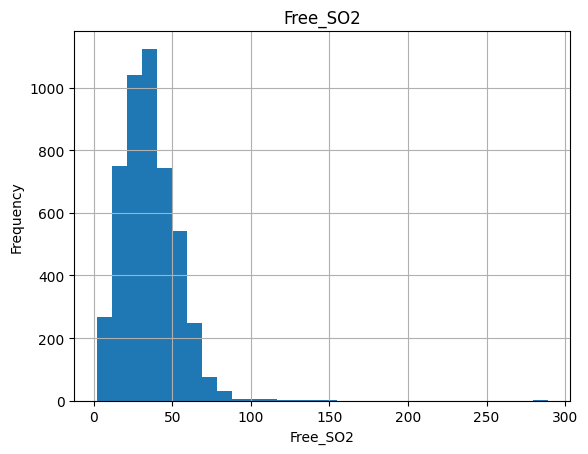

Observation (Free_SO2): Right-skewed (skew=1.41). Most wines have Free SO2 between 2-100 mg/dm³, with a long tail of higher values.


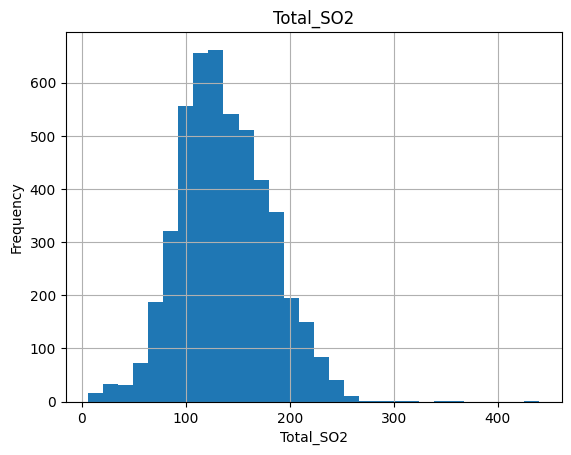

Observation (Total_SO2): Near symmetric (skew=0.28). Roughly bell-shaped distribution centered around 134 mg/dm³.


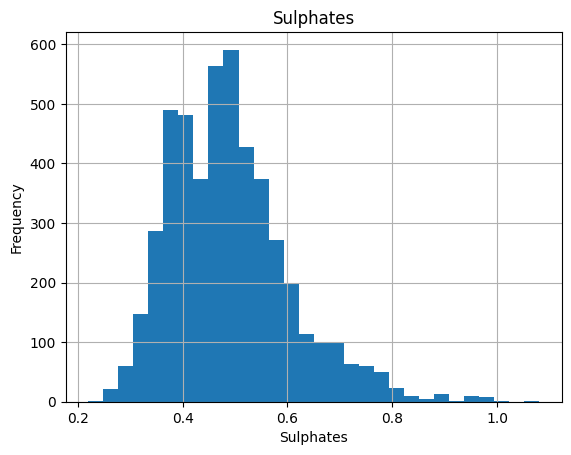

Observation (Sulphates): Moderately right-skewed (skew=0.98). Most wines have sulphate levels between 0.3-0.6 g/dm³.


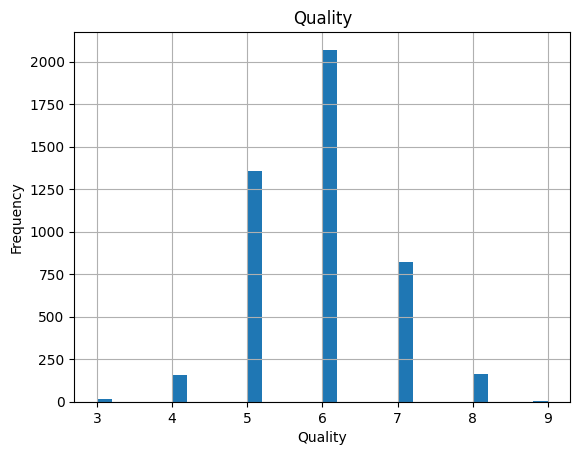

Observation (Quality): Near symmetric (skew=0.16). Most wines score 5 or 6, with very few scoring at the extremes (3 or 9).


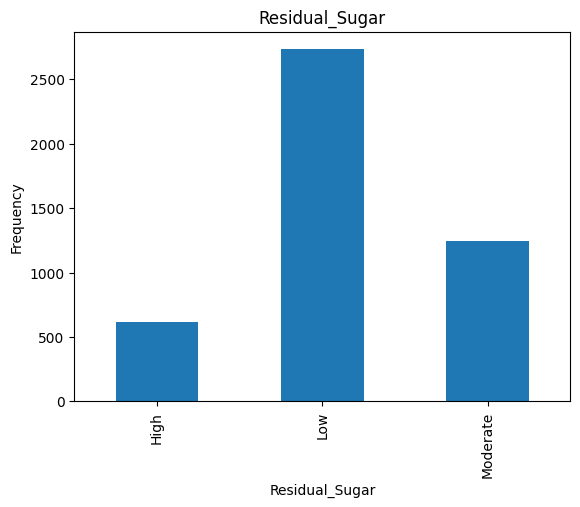

Observation (Residual_Sugar): Right-skewed. Most wines have Low residual sugar (2733), followed by Moderate (1243) and High (615).


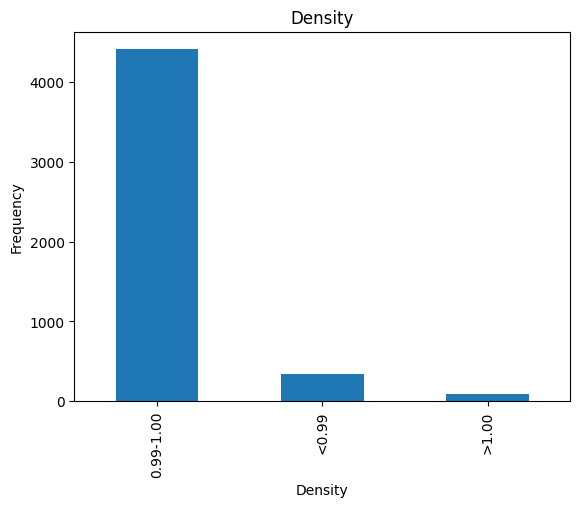

Observation (Density): Most wines fall in the 0.99-1.00 range (4409), with few wines below 0.99 (344) or above 1.00 (95).


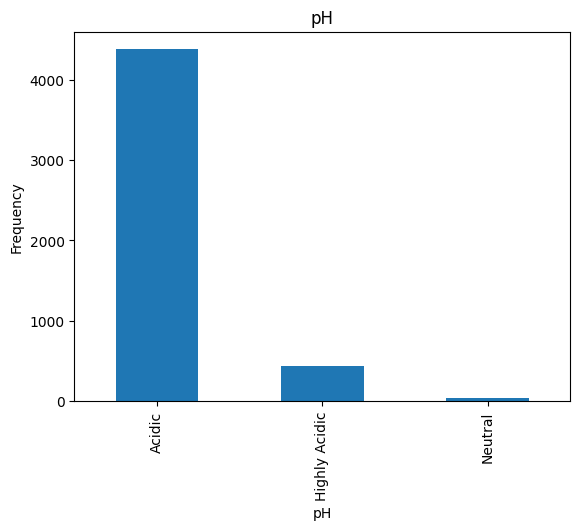

Observation (pH): Most wines are Acidic (4379), with a smaller group being Highly Acidic (432) and very few Neutral (37).


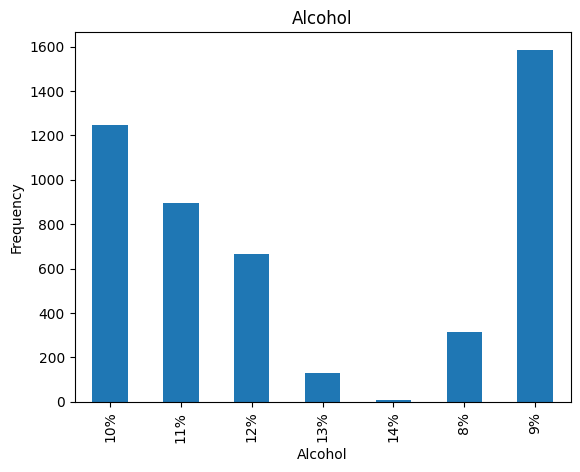

Observation (Alcohol): Alcohol content peaks at 9%, with a general decline at higher percentages. Very few wines reach 13-14%.


In [67]:
import matplotlib.pyplot as plt

numerical_observations = {
    'Fixed_Acidity':    'Slightly right-skewed (skew=0.65). Most wines have fixed acidity between 6-8 g/dm³, centered around 6.8.',
    'Volatile_Acidity': 'Moderately right-skewed (skew=1.58). Most wines have low volatile acidity, concentrated below 0.4 g/dm³, with a few high outliers.',
    'Citric_Acid':      'Right-skewed (skew=1.29). Values are concentrated at the lower end, with most wines below 0.5 g/dm³.',
    'Chlorides':        'Highly right-skewed (skew=5.04). The vast majority of wines have very low chloride levels near 0.04, with a few extreme outliers.',
    'Free_SO2':         'Right-skewed (skew=1.41). Most wines have Free SO2 between 2-100 mg/dm³, with a long tail of higher values.',
    'Total_SO2':        'Near symmetric (skew=0.28). Roughly bell-shaped distribution centered around 134 mg/dm³.',
    'Sulphates':        'Moderately right-skewed (skew=0.98). Most wines have sulphate levels between 0.3-0.6 g/dm³.',
    'Quality':          'Near symmetric (skew=0.16). Most wines score 5 or 6, with very few scoring at the extremes (3 or 9).'
}

categorical_observations = {
    'Residual_Sugar': 'Right-skewed. Most wines have Low residual sugar (2733), followed by Moderate (1243) and High (615).',
    'Density':        'Most wines fall in the 0.99-1.00 range (4409), with few wines below 0.99 (344) or above 1.00 (95).',
    'pH':             'Most wines are Acidic (4379), with a smaller group being Highly Acidic (432) and very few Neutral (37).',
    'Alcohol':        'Alcohol content peaks at 9%, with a general decline at higher percentages. Very few wines reach 13-14%.'
}

for col, obs in numerical_observations.items():
    plt.figure()
    wine_data[col].hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    print(f"Observation ({col}):", obs)

for col, obs in categorical_observations.items():
    plt.figure()
    wine_data[col].value_counts().sort_index().plot(kind='bar')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()  
    print(f"Observation ({col}):", obs)

**c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

In [74]:
# Correlation matrix (exclude ID)
corr = wine_data.drop(columns=['ID']).corr()
print(corr['Quality'].sort_values(ascending=False))


Quality             1.000000
Alcohol             0.404470
Sulphates           0.052014
Free_SO2            0.021619
pH                  0.006139
Citric_Acid        -0.010606
Residual_Sugar     -0.095582
Fixed_Acidity      -0.110888
Total_SO2          -0.158617
Volatile_Acidity   -0.190884
Chlorides          -0.202765
Density            -0.209534
Name: Quality, dtype: float64


<span style="color:lightblue">
We investigate 4 pairs of variables that are chemically meaningful or expected to relate to wine quality:

**1. Alcohol vs Quality** — We expect higher alcohol content to correlate with higher quality scores, as alcohol is a key indicator of fermentation completeness.

**2. Volatile_Acidity vs Quality** — High volatile acidity (acetic acid) gives wine a vinegar-like taste, so we expect a negative relationship with quality.

**3. Free_SO2 vs Total_SO2** — Free SO2 is a component of Total SO2, so we expect a strong positive correlation between the two.

**4. Residual_Sugar vs Density** — Higher sugar content increases the density of wine, so we expect a positive relationship between these two variables.
</span>

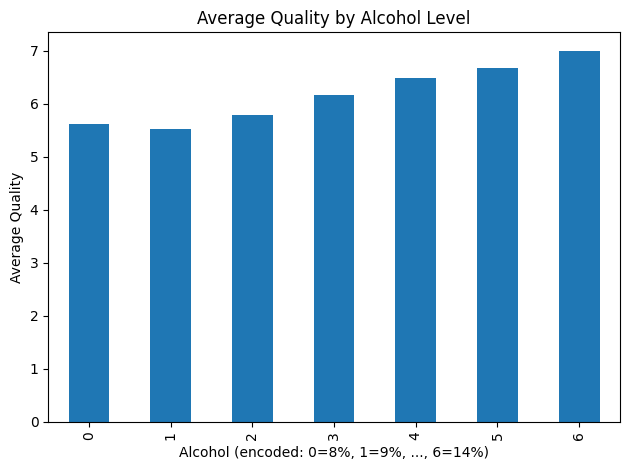

Correlation (Alcohol vs Quality): 0.404
Observation: Higher alcohol content is associated with higher average quality scores, suggesting a positive relationship.


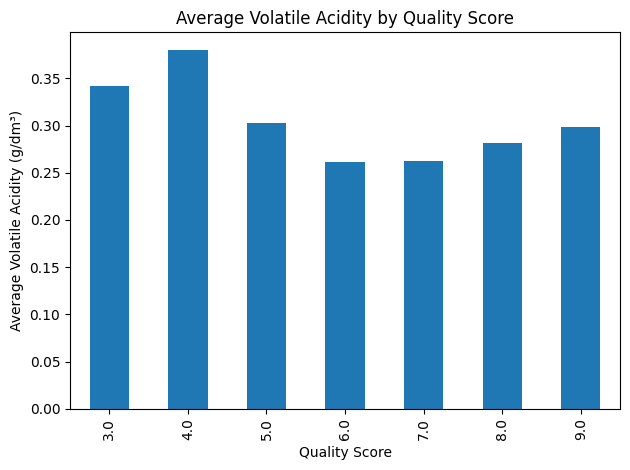

Correlation (Volatile_Acidity vs Quality): -0.191
Observation: Higher quality wines tend to have lower volatile acidity, confirming that excess acetic acid negatively affects wine quality.


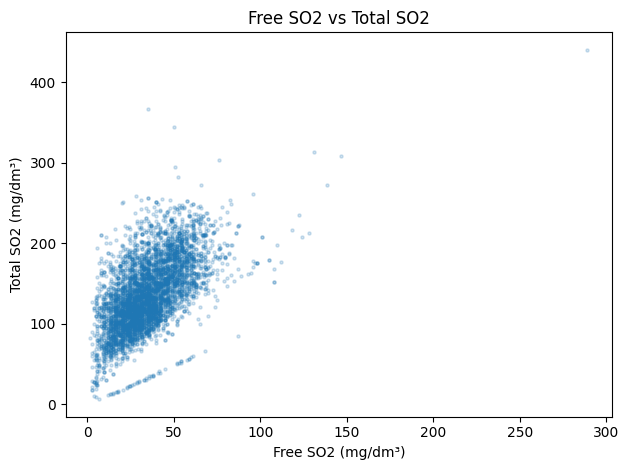

Correlation (Free_SO2 vs Total_SO2): 0.597
Observation: Strong positive correlation between Free SO2 and Total SO2, as expected since free SO2 is a direct component of total SO2.


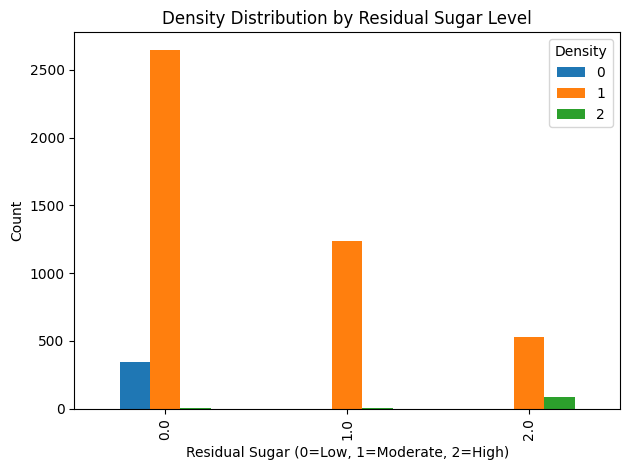

Correlation (Residual_Sugar vs Density): 0.303
Observation: Higher residual sugar levels are associated with higher density categories, consistent with sugar's contribution to wine density.


In [73]:
import matplotlib.pyplot as plt

# --- 1. Alcohol vs Quality ---
fig, ax = plt.subplots()
wine_data.groupby('Alcohol')['Quality'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average Quality by Alcohol Level')
ax.set_xlabel('Alcohol (encoded: 0=8%, 1=9%, ..., 6=14%)')
ax.set_ylabel('Average Quality')
plt.tight_layout()
plt.show()
print("Correlation (Alcohol vs Quality):", round(wine_data['Alcohol'].corr(wine_data['Quality']), 3))
print("Observation: Higher alcohol content is associated with higher average quality scores, suggesting a positive relationship.")

# --- 2. Volatile_Acidity vs Quality ---
fig, ax = plt.subplots()
wine_data.groupby('Quality')['Volatile_Acidity'].mean().plot(kind='bar', ax=ax)
ax.set_title('Average Volatile Acidity by Quality Score')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Average Volatile Acidity (g/dm³)')
plt.tight_layout()
plt.show()
print("Correlation (Volatile_Acidity vs Quality):", round(wine_data['Volatile_Acidity'].corr(wine_data['Quality']), 3))
print("Observation: Higher quality wines tend to have lower volatile acidity, confirming that excess acetic acid negatively affects wine quality.")

# --- 3. Free_SO2 vs Total_SO2 ---
fig, ax = plt.subplots()
ax.scatter(wine_data['Free_SO2'], wine_data['Total_SO2'], alpha=0.2, s=5)
ax.set_title('Free SO2 vs Total SO2')
ax.set_xlabel('Free SO2 (mg/dm³)')
ax.set_ylabel('Total SO2 (mg/dm³)')
plt.tight_layout()
plt.show()
print("Correlation (Free_SO2 vs Total_SO2):", round(wine_data['Free_SO2'].corr(wine_data['Total_SO2']), 3))
print("Observation: Strong positive correlation between Free SO2 and Total SO2, as expected since free SO2 is a direct component of total SO2.")

# --- 4. Residual_Sugar vs Density ---
fig, ax = plt.subplots()
wine_data.groupby('Residual_Sugar')['Density'].value_counts().unstack().plot(kind='bar', ax=ax)
ax.set_title('Density Distribution by Residual Sugar Level')
ax.set_xlabel('Residual Sugar (0=Low, 1=Moderate, 2=High)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print("Correlation (Residual_Sugar vs Density):", round(wine_data['Residual_Sugar'].corr(wine_data['Density']), 3))
print("Observation: Higher residual sugar levels are associated with higher density categories, consistent with sugar's contribution to wine density.")


## Part II: Modeling [12% of final grade]

### 1. Problem formulation [15% of Part II]

**a.** Formulate one regression problem and one classification based on the dataset, in **no more than 50 words**.

**Response.** 

**b.** State which problem (regression or classification) you would be investigating and why, in **no more than 20 words**.

**Response.** 

**c.** Clearly specify the dependent variable you are predicting, and its significance, in **no more than 20 words**

**Response.** 

### 2. Model training [30% of Part II]

**a.** Perform feature selection. For each variable, decide if you want to include it as a feature and provide a justification. You may leverage on your analysis in Part I: EDA and/or perform additional analysis.

**Response.** 

**b.** Split the dataset into train and test sets. Describe how you split step by step.

**Response.** 

**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.** 

**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable. 

**Response.** 

### 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.

**Response.** 

**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.

**Response.** 

**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.** 

### 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

**Response.** 

**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Response.** 

### 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.** 

**b.** List any references and sources you have cited.

**Response.** 